# To investigate why the graphs look the way they do when the bound on the precomputation cost is higher

## Imports

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from math import pi, sqrt, e, log
from functions import *
from scipy.optimize import minimize, Bounds
from tqdm import tqdm

## Constants

In [2]:
N = 2 ** 20
p = 1-e**-2 # our table coverage

## Check original graphs are produced with new functions

In [3]:
# Optimise 
# add vcost to bound the optimisation
def optimise_kj(N, p, alpha, factor):   # add v_cost if want vanilla cost to be set beforehand
    t = round(log(1-p)/log(1-N**(-1/3))) # Calculate t
    mt_target = N**(2/3) # our target mt
    m_0 = round(mt_target/(1-alpha))    # our starting m_0
    
    ## set the bound and target function
    # lower bounds and upper bounds for the input variables
    bound = Bounds([1 for i in range(t)], [float("inf") for i in range(t)])
    
    # our target function that needs to be > 0
    # instead of using the target function, we can use the cost function as the objective function
    # need to get the cost of a vanilla rainbow table with the same parameters
    
    # Const * P(vanilla) - P(cherry) > 0
    v_cost, m = vanilla_cost(N, m_0, t)
    v_cost = v_cost * factor
    ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - cost(x, N, m_0)[0]}

    # P(vanilla) - P(cherry) > 0 the same precomputation cost
    # but want the vanilla cost to be set beforehand
    # ineq_cons = {'type': 'ineq', 'fun' : lambda x: v_cost - cost(x, N, m_0)[0]}

    ## use 1 as starting values for cherry-picking
    starting_values = [1 for i in range(t)]
    
    ## call the optimizer
    # maximise the 
    res = minimize(lambda Kj: m_t(Kj, N, m_0), starting_values, bounds=bound, constraints=ineq_cons,method = "SLSQP", options={'disp': True, "maxiter": 5000000, "eps":0.5})
    
    ## res.x is the result of the optimization
    final_cost, m_values = cost(res.x, N, m_0) # calculate the final cost and m values
    return res.x, m_0, final_cost, m_values

## Run the function

In [4]:
def run_all_alpha():
    # different maximality factors
    alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    results = []
    factor = 1.125  # factor to multiply the vanilla cost with
    
    for alpha in alphas:
        K_js, m_0, final_cost, m_values = optimise_kj(N, p, alpha, factor)
        results.append([K_js, m_0, final_cost, m_values])
        
        plot_kjs(K_js, m_0, alpha, "$2^{20}$")
        
    return results

In [5]:
# run_all_alpha()

## Investigate alpha = 0.8

run optimisation for increased cost factors

In [6]:
def test_cost_factors(alpha):
    results = []
    factor = 5
    
    for i in tqdm(range(20), desc="Processing factors"):
        K_js, m_0, final_cost, m_values = optimise_kj(N, p, alpha, factor)
        plot_kjs_cost(K_js, m_0, alpha, factor)
        results.append([K_js, m_0, final_cost, m_values])
        # increment factor by 5
        factor += 5
        
    return results
    

In [7]:
# res = test_cost_factors(0.8)

In [8]:
# plot all the KJ's on the same graph
# cost_factors = list(range(5, 101, 5))
# legend_label = "Factor"
# title = "K curve where $α$ = 0.8 for different costs"
# plot_all_kj(res, cost_factors, legend_label, title)

## Investigate all other alpha values

In [9]:
def test_all_alpha():
    alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    # store results 
    results = []
    
    # extra bits for plotting the graph
    cost_factors = list(range(5, 101, 5))
    legend_label = "Factor"
    
    for alpha in tqdm(alphas, desc="Processing alphas"):
        res = test_cost_factors(alpha)
        results.append(res)
        
        # now plot them all on the same graph
        # get the title
        plot_all_kj(res, cost_factors, legend_label, alpha)
        
    return results

## Run the function

In [10]:
# results = test_all_alpha()

## Store the results

In [11]:
# There are 8 alpha results stored
# alpha = 0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95
# for each alpha, there are 20 cost factors stored
    # from 5 to 100 incrementing by 5
# for each cost factor : [K_js, m_0, final_cost, m_values]

# with open("higher_costs.pickle", "wb") as f:
#     pickle.dump(results, f)

## Plot all the results on the same graph

In [12]:
def plot_all_results(all_results):
    # extra bits for plotting the graph
    cost_factors = list(range(5, 101, 5))
    legend_label = "Factor"
    alphas = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
    
    plot_all(all_results, cost_factors, legend_label, alphas)


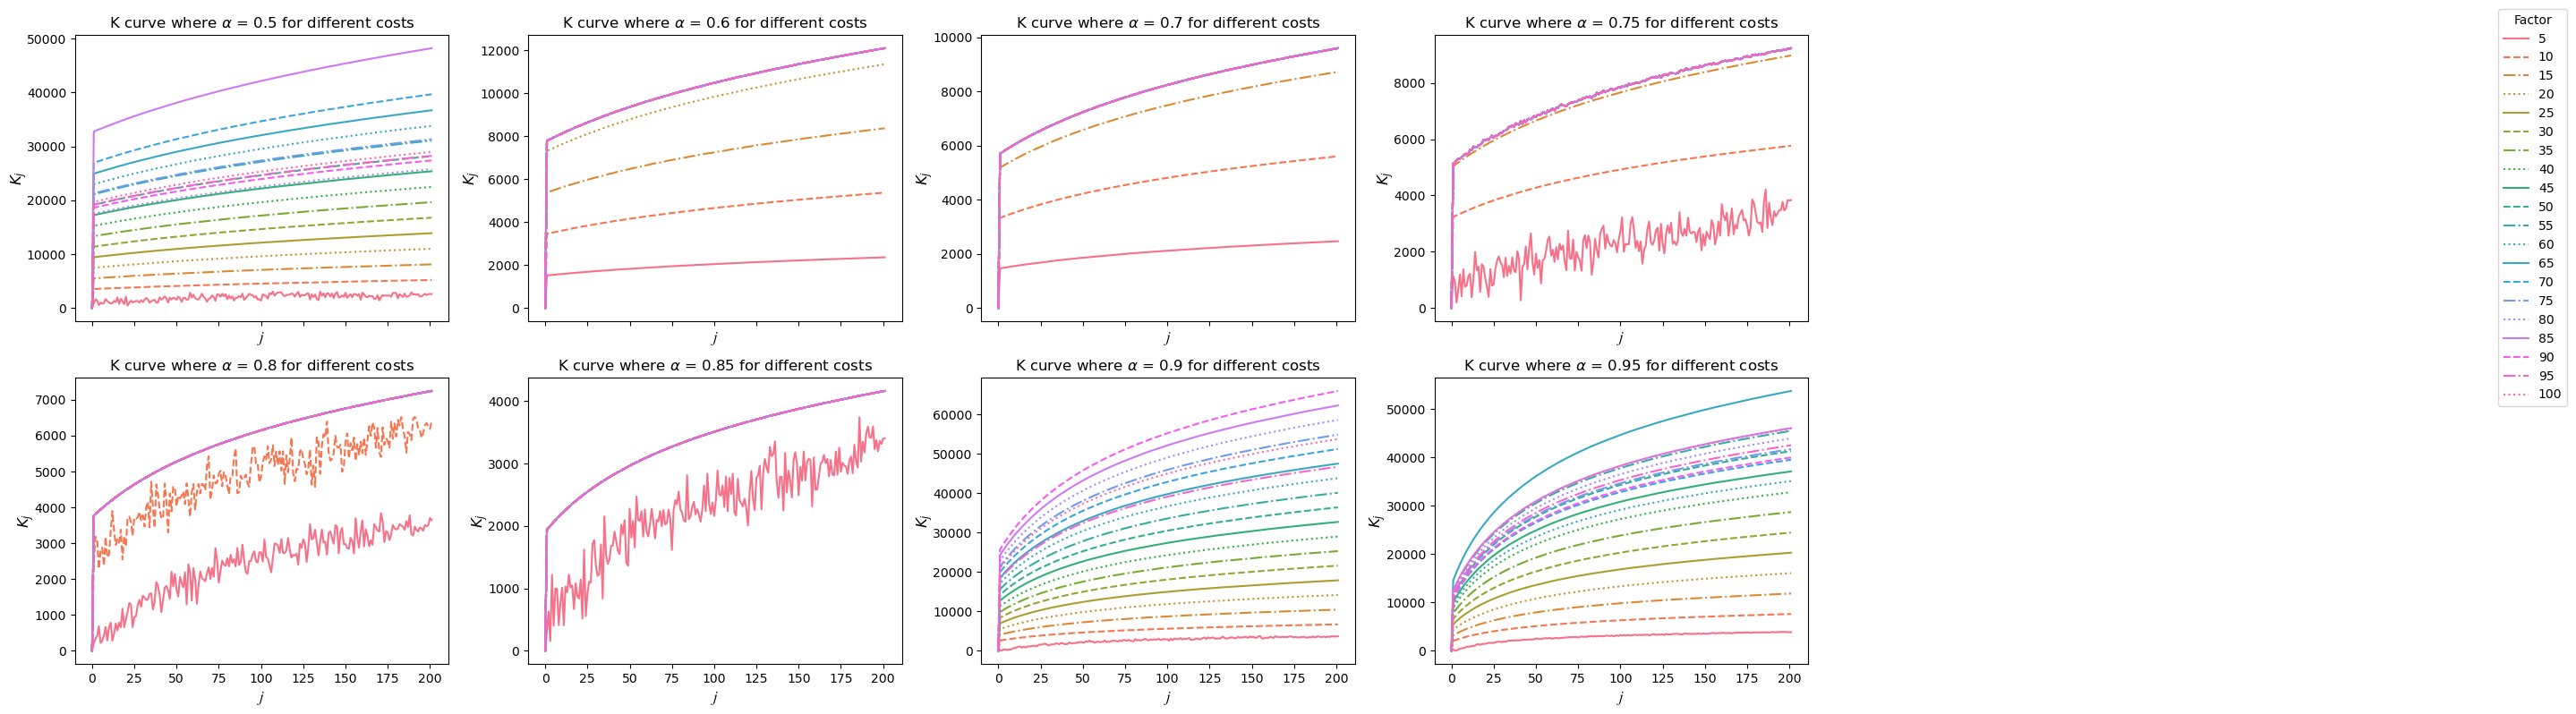

In [13]:
with open("higher_costs.pickle", "rb") as f:
    results_dict = pickle.load(f)
    
plot_all_results(results_dict)